# **(ADD THE NOTEBOOK NAME HERE)**

## Objectives

*  Use the clean dataset to explore the hypotheses:
* Customers who have been with the bank longer have a higher credit limit

* Customers with more bank products are less likely to leave the bank

* Customers with more inactive months are more likely to churn

* Customers with high inactivity and high transaction amounts are more likely to churn than other customer groups

## Inputs

* Using the Cleaned dataset from 'Dataset/CleanedData/BankChurners_cleaned.csv' file

* Python libraries include: pandas, numpy, matplotlib, seaborn, plotly
## Outputs

* Data visualisations: Created scatter plots, boxplots, bar charts and line plots

* Useful results were found in the data visualisation which helped to support / reject the hypotheses 
## Additional Comments

* If you have any additional comments that don't fit in the previous bullets, please state them here. 



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [2]:
import os
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Project 1/credit_card_analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [4]:
current_dir = os.getcwd()
current_dir

'/Users/nav/Desktop/Project 1/credit_card_analysis'

# Importing libraries and cleaned data

In [5]:
#import the the libraries i will be using for this project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [6]:
df_clean = pd.read_csv('Dataset/CleanedData/BankChurners_cleaned.csv')
df_clean.head() # Checking the first 5 rows of the cleaned dataset 

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


---

# Data Visualisation

# Hypothesis 1 (plotly)
Customers who have been with the bank longer have a higher credit limit

In [ ]:
# check the correlation between 'months_on_book' and 'Credit_Limit' using a scatter plot
df_clean[['Months_on_book', 'Credit_Limit']].corr()

In [ ]:
fig = px.scatter(
    df_clean,
    x='Months_on_book',
    y='Credit_Limit',
    title='Relationship Between Months with Bank and Credit Limit',
    labels={
        'Months_on_book': 'Months with Bank',
        'Credit_Limit': 'Credit Limit (£)'
    },
)
fig.show()

In [ ]:
average_credit = df_clean.groupby('Months_on_book')['Credit_Limit'].mean().round(2)

fig = px.line(
    average_credit,
    x=average_credit.index,
    y=average_credit.values,
    title='Average Credit Limit by Months with Bank',
    labels={
        'x': 'Months with Bank',
        'y': 'Average Credit Limit (£)'
    },
)
fig.show()

---

# Hypothesis 2 (Matplotlib)

Customers with more bank products are less like to churn 


In [ ]:
relationship_mean = df_clean.groupby('Attrition_Flag')['Total_Relationship_Count'].mean()
print(relationship_mean)

In [ ]:
plt.figure(figsize=(12,6))

relationship_mean.plot(kind='bar')

plt.title('Average Number of Bank Products by Customer Status')
plt.xlabel('Customer Status (0 = Existing, 1 = Attrited)')
plt.ylabel('Average Number of Products')

plt.show()




In [ ]:
plt.figure(figsize=(12,6))
existing = df_clean[df_clean['Attrition_Flag'] == 0]['Total_Relationship_Count']
attrited = df_clean[df_clean['Attrition_Flag'] == 1]['Total_Relationship_Count']

plt.boxplot(
    [existing, attrited],
    labels=['Existing', 'Attrited']
)

plt.title('Distribution of Bank Products by Customer Status')
plt.xlabel('Customer Status')
plt.ylabel('Total Relationship Count')

plt.show()

# Hypothesis 3 (seaborn)

Customers with more inactive months are more likely to churn

In [ ]:
inactive_mean = df_clean.groupby('Attrition_Flag')['Months_Inactive_12_mon'].mean().round(2)
print(inactive_mean)

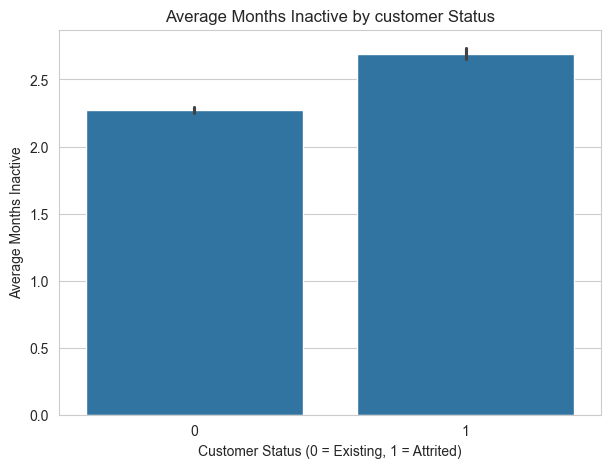

In [7]:
sns.set_style('whitegrid')
plt.figure(figsize=(7,5))

sns.barplot(data=df_clean, x='Attrition_Flag', y='Months_Inactive_12_mon')
plt.title('Average Months Inactive by customer Status')
plt.xlabel('Customer Status (0 = Existing, 1 = Attrited)')
plt.ylabel('Average Months Inactive')

plt.show()

In [8]:
df_clean.groupby('Attrition_Flag')['Contacts_Count_12_mon'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,2.36,1.08,0.0,2.0,2.0,3.0,5.0
1,1627.0,2.97,1.09,0.0,2.0,3.0,4.0,6.0


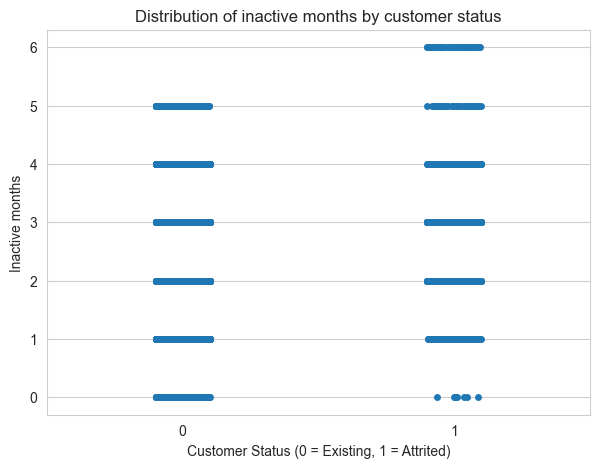

In [9]:
sns.set_style('whitegrid')
plt.figure(figsize=(7,5))

sns.stripplot(data=df_clean, x='Attrition_Flag', y='Contacts_Count_12_mon')

plt.title('Distribution of inactive months by customer status')
plt.xlabel('Customer Status (0 = Existing, 1 = Attrited)')
plt.ylabel('Inactive months')

plt.show()

/var/folders/l0/lvgdkkwj72sd1m4qyfcktzq80000gn/T/ipykernel_8889/2799989467.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




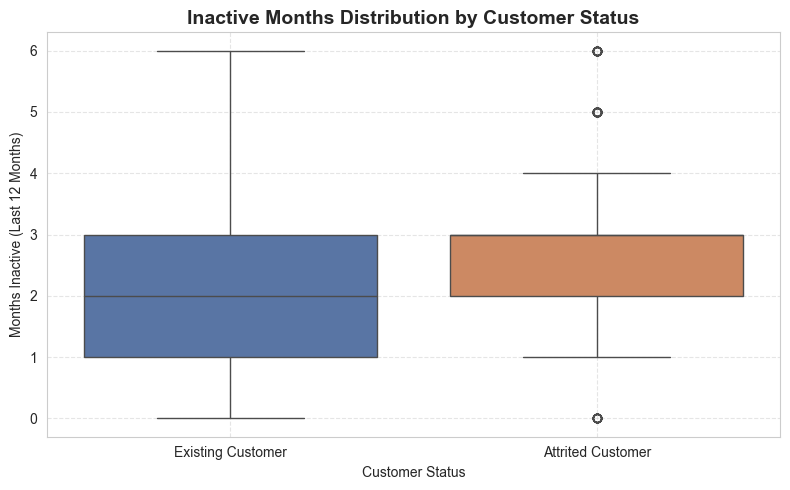

In [16]:
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='Attrition_Flag',
    y='Months_Inactive_12_mon',
    palette=['#4C72B0', '#DD8452']
)

plt.title(
    'Inactive Months Distribution by Customer Status',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Customer Status')
plt.ylabel('Months Inactive (Last 12 Months)')

plt.xticks(
    [0, 1],
    ['Existing Customer', 'Attrited Customer']
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Hypothesis 4 (Plotly)

Customers with high inactivity and high transaction amounts are more likely to churn than other customer groups.

In [13]:
median_spend = df_clean['Total_Trans_Amt'].median()

df_clean['Spend_Group'] = df_clean['Total_Trans_Amt'].apply(
    lambda x: 'High Spend' if x >= median_spend else 'Low Spend'
)


In [14]:
median_inactive = df_clean['Months_Inactive_12_mon'].median()

df_clean['Inactive_Group'] = df_clean['Months_Inactive_12_mon'].apply(
    lambda x: 'High Inactivity' if x >= median_inactive else 'Low Inactivity'
)

df_clean['Customer_Group'] = (
    df_clean['Inactive_Group'] + ' / ' + df_clean['Spend_Group']
)

grouped = (df_clean.groupby('Customer_Group')['Attrition_Flag'].mean().round(2).reset_index())
grouped['churn_rate'] = grouped['Attrition_Flag'] * 100

In [15]:
sns.set_style('whitegrid')


fig = px.bar(
    grouped,
    x='Customer_Group',
    y='churn_rate',
    title='Churn Rate by Inactivity and Spending Groups',
    labels={
        'Customer_Group': 'Customer Behaviour Group',
        'Churn Rate': 'Churn Rate (%)'
    },
    text = 'churn_rate',
    color = 'Customer_Group'
    )
fig.show()


In [20]:
sns.set_style('whitegrid')
plt.figure(figsize=(12,6))
fig = px.box(
    df_clean,
    x='Customer_Group',
    y='Total_Trans_Amt',
    title= 'Transaction Amount Distribution by Customer Group',
    labels={
        'Customer_Group': 'Customer Group',
        'Total_Trans_Amt': 'Total Transaction Amount '
    }
)

fig.show()

<Figure size 1200x600 with 0 Axes>

# Hypothesis 5 - Credit utilisation and customer churn

customers with higher credit utilisation rattios are less likely to chrun

In order to investiagte this hypothesis we would need to use the following columns: 'Avg_Utilization_Ratio'
'Total_Trans_Ct'
'Toatal_Trans_Amt'
'Attrition_Flag 

These columns will help us visualise customer engagement and credit card usage behaviour

Credit utilisation ratio Vs Transction count

we will visualise this using a scatter plot to see whether customers with high credit utilsation also demonstrate higher transaction activity
A positive relationship between utilisation and transaction activity would support the hypothesis that customers who actively use their credit card are less likely to leave the bank

In [23]:
fig = px.scatter(
    df_clean,
    x="Avg_Utilization_Ratio",
    y="Total_Trans_Ct",
    color="Attrition_Flag",
    hover_data=[
        "Customer_Age",
        "Credit_Limit",
        "Total_Trans_Amt",
        "Total_Revolving_Bal"
    ],
    title="Credit Utilisation Ratio vs Transaction Count by Customer Attrition",
    labels={
        "Avg_Utilization_Ratio": "Average Credit Utilisation Ratio",
        "Total_Trans_Ct": "Total Transaction Count",
        "Attrition_Flag": "Customer Status"
    }
)

fig.update_layout(
    xaxis_title="Average Credit Utilisation Ratio",
    yaxis_title="Total Transaction Count",
    legend_title="Customer Status"
)
fig.show()

# Interpretation
The scatter plot shows the relationship between credit utilisation, transaction activity, and customer attrition.

The scatter plot indicates that customers who remained with the bank generally show higher transaction activity alongside varying levels of credit utilisation. This suggests that active use of credit card services may contribute to customer retention.But credit utilisation alone does not fully explain customer churn, as other factors such as inactivity levels, number of products, and customer engagement may also influence retention.

# Credit Utilisation Distribution by Customer Status

This histogram compares the distribution of credit utilisation ratios between existing and attrited customers.

By comparing where customers are concentrated, it is possible to determine whether customers who remain with the bank generally utilise a greater proportion of their available credit than customers who leave.

If the hypothesis is supported, existing customers should be more concentrated at higher utilisation ratios than attrited customers..

In [30]:
fig = px.histogram(
    df_clean,
    x="Avg_Utilization_Ratio",
    color=df_clean["Attrition_Flag"].replace({
    0: "Existing Customer",
    1: "Attrited Customer"
}),
    barmode="overlay",
    opacity=0.7,
    nbins=25,
    title="Credit Utilisation Ratio by Customer Status",
    labels={
        "Avg_Utilization_Ratio": "Credit Utilisation Ratio",
        "Attrition_Flag": "Customer Status"
    }
)

fig.update_layout(
    xaxis_title="Credit Utilisation Ratio",
    yaxis_title="Number of Customers"
)

fig.show()

# Interpretation
This histogram compares the credit utilisation ratios of existing customers and attrited customers.

Credit utilisation ratio shows how much of a customer's available credit is being used. By comparing the distributions of both customer groups, it is possible to identify whether customers who remain with the bank tend to use more of their available credit than customers who leave.

If the existing customer distribution is concentrated at higher utilisation ratios, this supports the hypothesis that customers who actively use their credit cards are less likely to churn. This may suggest that customers who regularly rely on their credit card services have a stronger relationship with the bank and are more likely to remain customers.

# Conclusion
The visualisations showed differences in credit utilisation behaviour between existing and attrited customers, providing insight into how customers use their available credit. The results suggest that credit utilisation may be linked to customer engagement, as customers who actively use their credit card services appear more likely to maintain their relationship with the bank.

Overall, the findings provide support for the hypothesis that customers with higher credit utilisation ratios are less likely to churn. This suggests that customers who regularly use their available credit may be more engaged with the bank's products and services, reducing the likelihood of attrition.

NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)
